# 05 — TFNBS parameter sweep (extent × height exponents)

TFNBS integrates across thresholds with two tunable exponents:

- **E (extent)** — weight on cluster extent. Larger E → favours
  large clusters.
- **H (height)** — weight on supra-threshold t-statistic magnitude.
  Larger H → favours strong peaks.

Passing **same-length lists** to `e` and `h` runs several parameter
pairs in a single permutation loop — you get a sensitivity sweep
without paying for each combination separately. The output p-value
arrays then carry an extra trailing parameter dimension.

Runtime target: ~45 s.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from conninfpy import (
    TopologyDatasetGenerator,
    compute_p_val,
    fisher_r_to_z,
)

In [2]:
N, n_sub = 40, 25
gen = TopologyDatasetGenerator(n_nodes=N, n_modules=4, seed=11)
ds = gen.generate("hub", effect_size=0.35,
                  n_samples=n_sub, time_points=80)
g1, g2 = fisher_r_to_z(ds.group1), fisher_r_to_z(ds.group2)
gt = ds.effect_mask > 0
iu = np.triu_indices(N, k=1)

## 1. Single run with **zipped** `(e, h)` pairs

Passing lists runs several parameter configurations inside one
permutation loop. Per the API contract, `e` and `h` are **zipped
pairwise** (not a Cartesian grid) — they must have the same length.
Output gains a trailing parameter dimension.

The canonical TFCE defaults are (E=0.5, H=2.0). We also probe an
extent-heavy corner (0.8, 1.0) and a height-heavy corner (0.2, 3.0).

In [3]:
e_pairs = [0.2, 0.4, 0.5, 0.6, 0.8]
h_pairs = [3.0, 2.5, 2.0, 1.5, 1.0]

p = compute_p_val(
    g1, g2,
    test_type="two-sample", method="tfnbs",
    e=e_pairs, h=h_pairs, n=10,
    n_permutations=300, random_state=0, use_mp=False,
)
p['g2>g1'].shape
# (N, N, len(e_pairs)) — one slice per (E, H) pair.

(40, 40, 5)

## 2. Power / FPR along the (E, H) trajectory

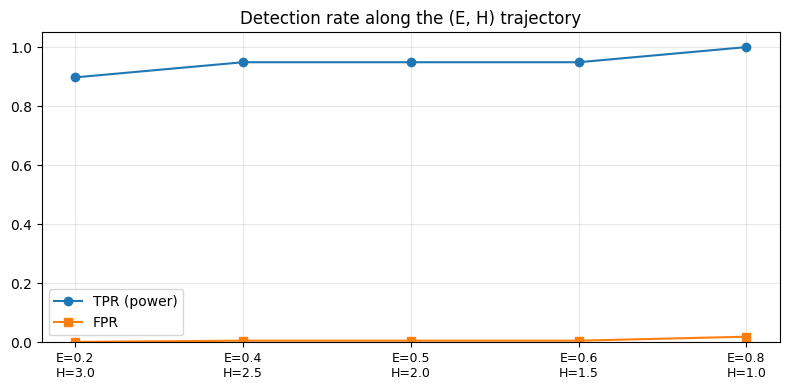

In [4]:
alpha = 0.05
n_p = len(e_pairs)
tpr = np.zeros(n_p)
fpr = np.zeros(n_p)
for k in range(n_p):
    sig = p['g2>g1'][:, :, k] < alpha
    tp = int((sig[iu] & gt[iu]).sum())
    fp = int((sig[iu] & ~gt[iu]).sum())
    fn = int((~sig[iu] & gt[iu]).sum())
    tn = int((~sig[iu] & ~gt[iu]).sum())
    tpr[k] = tp / max(tp + fn, 1)
    fpr[k] = fp / max(fp + tn, 1)

labels = [f"E={e:.1f}\nH={h:.1f}" for e, h in zip(e_pairs, h_pairs)]
x = np.arange(n_p)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, tpr, "-o", label="TPR (power)")
ax.plot(x, fpr, "-s", label="FPR")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
ax.legend(); ax.set_title("Detection rate along the (E, H) trajectory")
plt.tight_layout(); plt.show()

## 3. Visual comparison at the endpoints

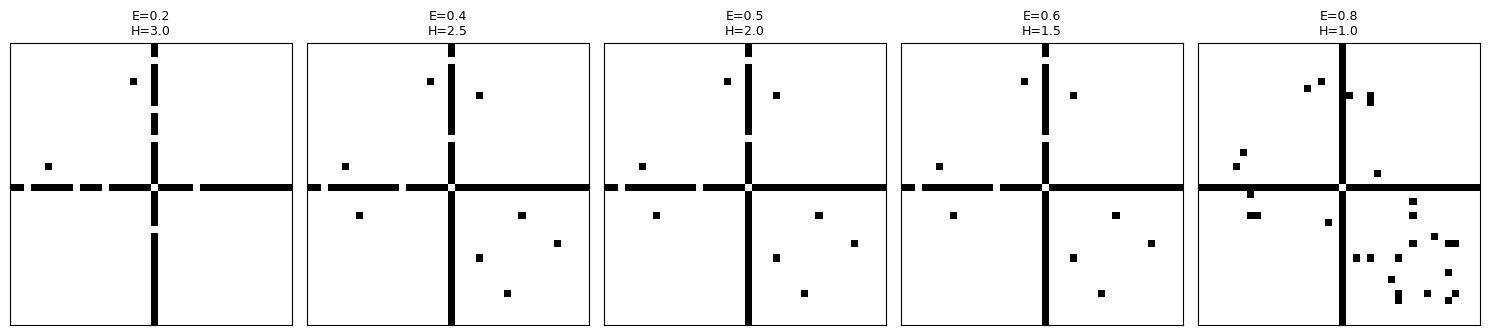

In [5]:
fig, axes = plt.subplots(1, n_p, figsize=(3 * n_p, 3.5))
for k, ax in enumerate(axes):
    sig = p['g2>g1'][:, :, k] < alpha
    ax.imshow(sig, cmap="Greys")
    ax.set_title(labels[k], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Discussion

- For a hub topology, moderate (E=0.5, H=2) is a safe default.
  Very large H hurts if the planted effect is diffuse rather than
  peaky.
- The cost of a multi-param sweep is close to a single run: the
  permutations dominate, and the enhancement is cheap.
- `compute_p_val_glm` supports the same list-valued `e`/`h`.
- In reporting, pick a **single** (E, H) a priori (canonical TFCE
  defaults or a choice motivated by literature) — sweep-and-pick
  inflates false positives. This notebook is for characterizing
  method behaviour, not for selecting parameters on your data.